Dataset Shape: (891, 15)

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB

--- Missing Value Percentages ---
age         

C:\Users\HP\AppData\Local\Temp\ipykernel_25972\2330755375.py:30: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['age'].fillna(df['age'].median(), inplace=True)


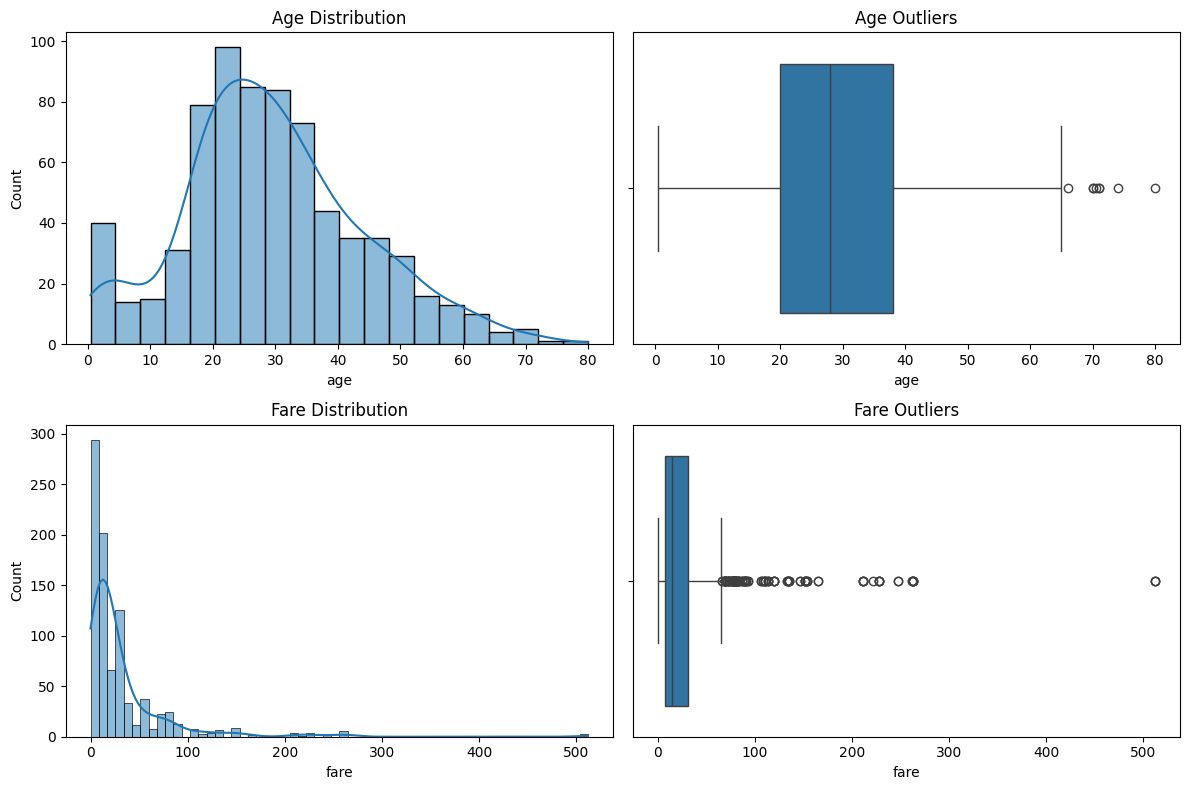

Number of outliers in age: 8
Number of outliers in fare: 114

Fare Mean: 32.10, Median: 14.45, Mode: 8.05
Fare distribution is Right-Skewed because Mean > Median > Mode.

--- Survival Rates ---
By Sex:
 sex
female    0.740385
male      0.188908
Name: survived, dtype: float64

By Pclass:
 pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64

By Sex and Pclass:
 sex     pclass
female  1         0.967391
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: survived, dtype: float64


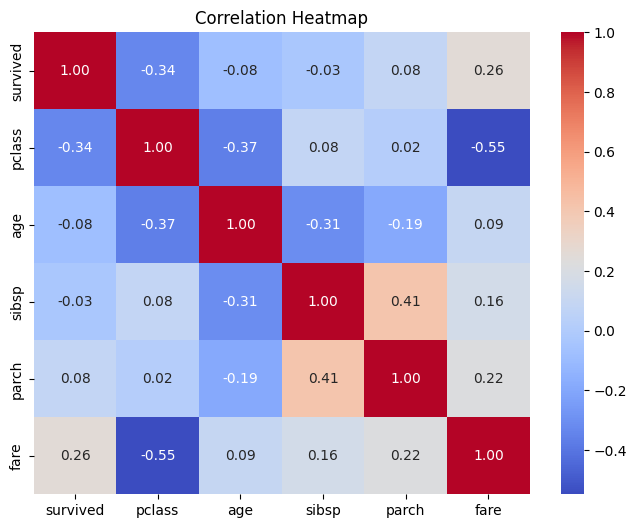


Top 2 Correlation Pairs:
pclass  fare     0.548193
sibsp   parch    0.414542
dtype: float64


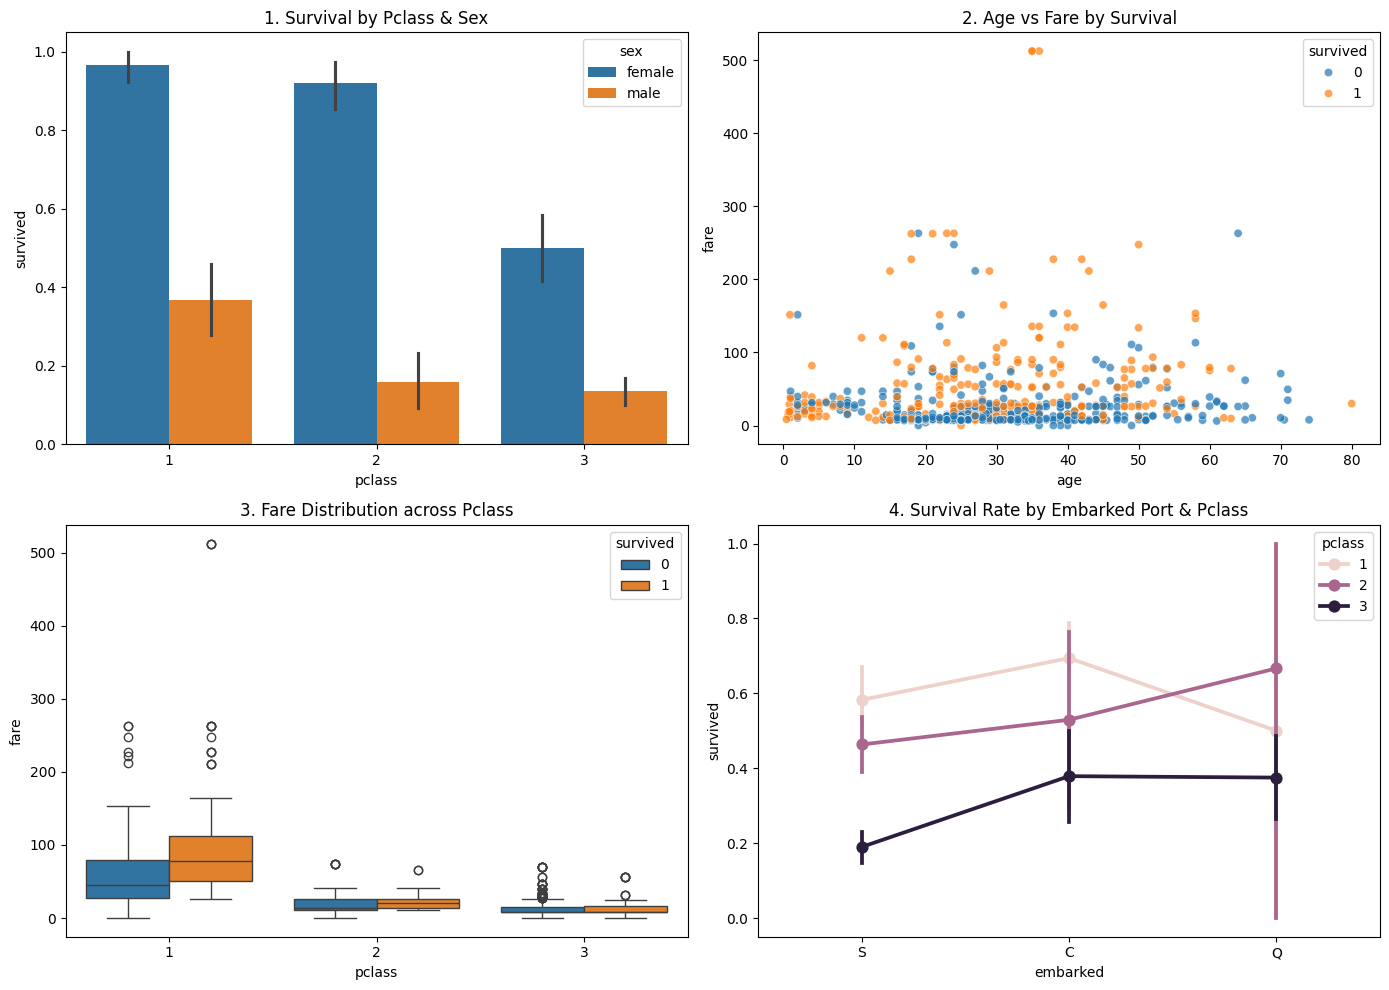


--- Standardization Check (Z-score) ---
Age Z-score Mean: 0.00, Std: 1.00
Fare Z-score Mean: 0.00, Std: 1.00


In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Task 1: Load Dataset & Initial Profiling
# ==========================================
df = sns.load_dataset('titanic')

# Save offline fallback
df.to_csv('titanic.csv', index=False)

print("Dataset Shape:", df.shape)
print("\n--- Dataset Info ---")
df.info()

print("\n--- Missing Value Percentages ---")
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage[missing_percentage > 0])

# ==========================================
# Task 2: Missing Value Treatment
# ==========================================
# Rule: <5% drop rows, 5-30% impute, >30% drop/encode missing
# 'embarked' & 'embark_town' < 5% -> drop rows
df.dropna(subset=['embarked', 'embark_town'], inplace=True)

# 'age' ~19.8% -> impute with median
df['age'].fillna(df['age'].median(), inplace=True)

# 'deck' >70% -> drop column due to high missing rate
df.drop(columns=['deck'], inplace=True)

print("\nMissing values after cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# ==========================================
# Task 3: Univariate Analysis (Age & Fare)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Age distribution & Boxplot
sns.histplot(df['age'], kde=True, ax=axes[0, 0]).set_title('Age Distribution')
sns.boxplot(x=df['age'], ax=axes[0, 1]).set_title('Age Outliers')

# Fare distribution & Boxplot
sns.histplot(df['fare'], kde=True, ax=axes[1, 0]).set_title('Fare Distribution')
sns.boxplot(x=df['fare'], ax=axes[1, 1]).set_title('Fare Outliers')

plt.tight_layout()
plt.show()

# IQR Rule Outlier Calculation
for col in ['age', 'fare']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]
    print(f"Number of outliers in {col}: {len(outliers)}")

# Fare Statistics & Skewness
mean_fare = df['fare'].mean()
median_fare = df['fare'].median()
mode_fare = df['fare'].mode()[0]
print(f"\nFare Mean: {mean_fare:.2f}, Median: {median_fare:.2f}, Mode: {mode_fare:.2f}")
print("Fare distribution is Right-Skewed because Mean > Median > Mode.")

# ==========================================
# Task 4: Bivariate Analysis & Correlation
# ==========================================
print("\n--- Survival Rates ---")
print("By Sex:\n", df.groupby('sex')['survived'].mean())
print("\nBy Pclass:\n", df.groupby('pclass')['survived'].mean())
print("\nBy Sex and Pclass:\n", df.groupby(['sex', 'pclass'])['survived'].mean())

# Correlation Matrix (Restricted to 6 numeric columns)
numeric_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Top 2 Strongest Correlations (excluding self correlation)
abs_corr = corr_matrix.abs().unstack()
abs_corr = abs_corr[abs_corr < 1.0].sort_values(ascending=False)
print("\nTop 2 Correlation Pairs:")
print(abs_corr.iloc[:4:2])

# ==========================================
# Task 5: Multivariate Data Story Charts
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(data=df, x='pclass', y='survived', hue='sex', ax=axes[0, 0]).set_title('1. Survival by Pclass & Sex')
sns.scatterplot(data=df, x='age', y='fare', hue='survived', alpha=0.7, ax=axes[0, 1]).set_title('2. Age vs Fare by Survival')
sns.boxplot(data=df, x='pclass', y='fare', hue='survived', ax=axes[1, 0]).set_title('3. Fare Distribution across Pclass')
sns.pointplot(data=df, x='embarked', y='survived', hue='pclass', ax=axes[1, 1]).set_title('4. Survival Rate by Embarked Port & Pclass')

plt.tight_layout()
plt.show()

# ==========================================
# Task 6: Exploratory Standardization Check
# ==========================================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[['age', 'fare']])
df_scaled = pd.DataFrame(scaled_data, columns=['age_z', 'fare_z'])

print("\n--- Standardization Check (Z-score) ---")
print(f"Age Z-score Mean: {df_scaled['age_z'].mean():.2f}, Std: {df_scaled['age_z'].std():.2f}")
print(f"Fare Z-score Mean: {df_scaled['fare_z'].mean():.2f}, Std: {df_scaled['fare_z'].std():.2f}")

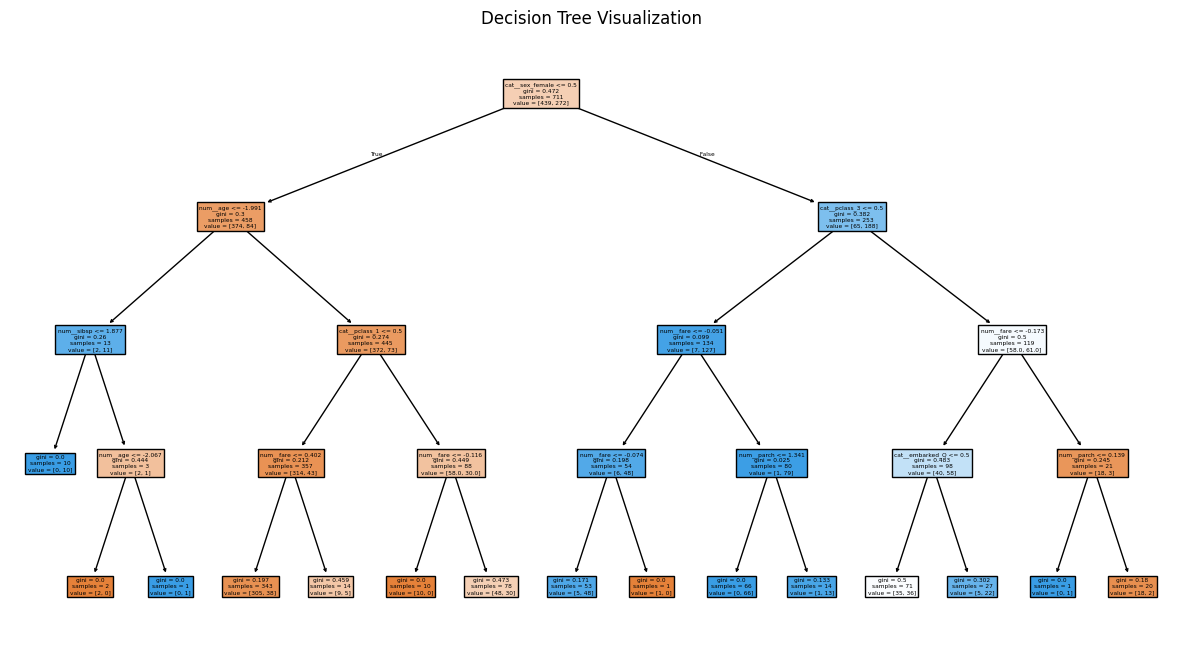

=== Task 10: Classification Model Comparison Table ===
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.814607   0.796610  0.691176  0.740157  0.859626
1        Decision Tree  0.808989   0.814815  0.647059  0.721311  0.856016
2        Random Forest  0.786517   0.758621  0.647059  0.698413  0.823262

=== Task 11: SMOTE Random Forest F1 Score === 0.7121212121212122

=== Task 12: GridSearch Results ===
Best Parameters: {'max_depth': 5, 'n_estimators': 50}
OOB Score: 0.810126582278481

=== Task 13: Fare Regression Metrics ===
MAE: 20.6709595133787
RMSE: 42.44272351273909
R2 Score: 0.32480404124736495

=== Task 15: Success ===
Full pipeline successfully saved to disk as 'titanic_model_pipeline.pkl'


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                                 roc_auc_score, confusion_matrix, mean_absolute_error,
                                 mean_squared_error, r2_score)
from imblearn.over_sampling import SMOTE
import joblib

# Load cleaned base dataset
df = sns.load_dataset('titanic')
df.dropna(subset=['embarked'], inplace=True)
df.drop(columns=['deck'], inplace=True)

# Define Features and Target
X = df[['sex', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'embarked']]
y = df['survived']

# Task 7: Stratified Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Task 8: Preprocessing Pipeline (Fit on train split only)
num_features = ['age', 'fare', 'sibsp', 'parch']
cat_features = ['sex', 'pclass', 'embarked']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

# Process train and test sets separately
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# Task 9 & 10: Train & Evaluate Classifiers
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=4),
    'Random Forest': RandomForestClassifier(random_state=42, oob_score=True)
}

results = []

for name, model in models.items():
    model.fit(X_train_prep, y_train)
    y_pred = model.predict(X_test_prep)
    y_prob = model.predict_proba(X_test_prep)[:, 1]
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

# Plot Decision Tree
plt.figure(figsize=(15, 8))
plot_tree(models['Decision Tree'], filled=True, feature_names=preprocessor.get_feature_names_out())
plt.title("Decision Tree Visualization")
plt.show()

# Display Model Evaluation Metrics Table
df_results = pd.DataFrame(results)
print("=== Task 10: Classification Model Comparison Table ===")
print(df_results)

# Task 11: Class Imbalance Handling using SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_prep, y_train)

rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_sm, y_train_sm)
y_pred_sm = rf_smote.predict(X_test_prep)
print("\n=== Task 11: SMOTE Random Forest F1 Score ===", f1_score(y_test, y_pred_sm))

# Task 12: Hyperparameter Tuning with GridSearchCV
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42, oob_score=True), param_grid, cv=3)
grid_search.fit(X_train_prep, y_train)

print("\n=== Task 12: GridSearch Results ===")
print("Best Parameters:", grid_search.best_params_)
print("OOB Score:", grid_search.best_estimator_.oob_score_)

# Task 13: Regression Side-task (Predicting Fare)
X_reg = df[['pclass', 'age', 'sibsp', 'parch', 'survived']]
y_reg = df['fare']

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

lin_reg = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', LinearRegression())
])
lin_reg.fit(X_tr_r, y_tr_r)
y_reg_pred = lin_reg.predict(X_te_r)

print("\n=== Task 13: Fare Regression Metrics ===")
print("MAE:", mean_absolute_error(y_te_r, y_reg_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_te_r, y_reg_pred)))
print("R2 Score:", r2_score(y_te_r, y_reg_pred))

# Task 15: Save Complete Fitted Pipeline Artifact
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', grid_search.best_estimator_)
])
full_pipeline.fit(X_train, y_train)

joblib.dump(full_pipeline, 'titanic_model_pipeline.pkl')
print("\n=== Task 15: Success ===")
print("Full pipeline successfully saved to disk as 'titanic_model_pipeline.pkl'")